In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.metrics as metrics 
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import math
import warnings
import xgboost as xgb
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt
#!pip install statsmodels
#!pip install xgboost
import statsmodels.api as sm
%matplotlib inline

In [2]:
## Data

In [3]:
df = pd.read_pickle("df_after_feature_eng_1.pkl")
print(df.isnull().sum())  # Should match the saved df

track_id                              0
track_popularity                      0
track_album_id                        0
danceability                          0
energy                                0
key                                   0
loudness                              0
mode                                  0
speechiness                           0
acousticness                          0
instrumentalness                      0
liveness                              0
valence                               0
tempo                                 0
track_album_release_date_converted    0
playlist_count_per_song               0
duration_minutes                      0
playlist_genre_count_per_song         0
track_artist_na                       0
track_album_release_date_na           0
danceability_na                       0
energy_na                             0
loudness_na                           0
speechiness_na                        0
acousticness_na                       0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   track_id                            28356 non-null  string 
 1   track_popularity                    28356 non-null  int64  
 2   track_album_id                      28356 non-null  string 
 3   danceability                        28356 non-null  float64
 4   energy                              28356 non-null  float64
 5   key                                 28356 non-null  int64  
 6   loudness                            28356 non-null  float64
 7   mode                                28356 non-null  int64  
 8   speechiness                         28356 non-null  float64
 9   acousticness                        28356 non-null  float64
 10  instrumentalness                    28356 non-null  float64
 11  liveness                            28356 non-

In [5]:
### Encoding Categorial 

In [6]:
 ## transforming object and encoding 

In [7]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Process all object or string columns
for column in df.columns:
    if df[column].dtype == 'object' or df[column].dtype == 'string':  # Check for object or string type
        df.loc[:, column] = label_encoder.fit_transform(df[column].astype(str))  # Apply LabelEncoder


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   track_id                            28356 non-null  int32  
 1   track_popularity                    28356 non-null  int64  
 2   track_album_id                      28356 non-null  int32  
 3   danceability                        28356 non-null  float64
 4   energy                              28356 non-null  float64
 5   key                                 28356 non-null  int64  
 6   loudness                            28356 non-null  float64
 7   mode                                28356 non-null  int64  
 8   speechiness                         28356 non-null  float64
 9   acousticness                        28356 non-null  float64
 10  instrumentalness                    28356 non-null  float64
 11  liveness                            28356 non-

In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['language_category'] = label_encoder.fit_transform(df['language_category'].astype(str))
df['track_artist_type'] = label_encoder.fit_transform(df['track_artist_type'].astype(str))


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   track_id                            28356 non-null  int32  
 1   track_popularity                    28356 non-null  int64  
 2   track_album_id                      28356 non-null  int32  
 3   danceability                        28356 non-null  float64
 4   energy                              28356 non-null  float64
 5   key                                 28356 non-null  int64  
 6   loudness                            28356 non-null  float64
 7   mode                                28356 non-null  int64  
 8   speechiness                         28356 non-null  float64
 9   acousticness                        28356 non-null  float64
 10  instrumentalness                    28356 non-null  float64
 11  liveness                            28356 non-

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
track_id,28356.0,14177.500000,8185.816453,0.000,7088.750000,14177.500000,21266.250000,28355.000000
track_popularity,28356.0,39.329771,23.702376,0.000,21.000000,42.000000,58.000000,100.000000
track_album_id,28356.0,11260.283503,6500.369980,0.000,5627.000000,11237.500000,16870.250000,22544.000000
danceability,28356.0,0.672183,0.092506,0.462,0.612000,0.672183,0.737000,0.859000
energy,28356.0,0.734714,0.130118,0.447,0.647000,0.734714,0.835000,0.975000
key,28356.0,5.368000,3.613904,0.000,2.000000,6.000000,9.000000,11.000000
loudness,28356.0,-6.134498,1.634820,-10.109,-7.098000,-6.134498,-4.966750,-2.909000
mode,28356.0,0.565489,0.495701,0.000,0.000000,1.000000,1.000000,1.000000
speechiness,28356.0,0.065721,0.033201,0.000,0.041000,0.062600,0.073000,0.179000
acousticness,28356.0,0.092012,0.093090,0.000,0.014375,0.079700,0.122000,0.382000


In [12]:
#df.isna().sum()

In [13]:
import matplotlib.pyplot as plt

plt.show()

In [14]:
df.corr(method='spearman')

,track_id,track_popularity,track_album_id,danceability,energy,key,loudness,mode,speechiness,acousticness,...,track_album_release_date_na,danceability_na,energy_na,loudness_na,speechiness_na,acousticness_na,track_album_release_year,track_album_release_month,language_category,track_artist_type
track_id,1.000000,0.011475,-0.001915,0.000031,-0.010119,-0.005386,-0.004861,-0.006645,-0.002442,0.015262,...,-0.007574,0.003545,0.006415,0.000764,-0.008469,-0.000066,-0.002013,0.008356,0.010071,-0.010151
track_popularity,0.011475,1.000000,0.005843,0.031744,-0.094594,-0.008439,0.040044,0.017713,-0.000611,0.118290,...,-0.031221,0.020546,0.018618,-0.045422,0.007290,0.058798,0.131255,0.072088,0.024119,-0.040182
track_album_id,-0.001915,0.005843,1.000000,0.005621,-0.000491,0.003516,0.000675,0.002736,-0.010585,0.006929,...,0.009387,-0.006328,-0.001407,0.005327,-0.022909,0.010583,0.017254,-0.003027,-0.008199,-0.007365
danceability,0.000031,0.031744,0.005621,1.000000,-0.127824,0.008360,-0.059807,-0.038817,0.187830,0.128031,...,-0.033253,-0.027752,-0.038335,-0.025500,0.088221,-0.020476,0.042995,0.028319,0.068602,-0.003905
energy,-0.010119,-0.094594,-0.000491,-0.127824,1.000000,0.002615,0.441702,0.009214,0.081293,-0.310524,...,0.000487,-0.012236,-0.020515,-0.063489,-0.096657,-0.218041,-0.023972,-0.027393,-0.029996,0.048191
key,-0.005386,-0.008439,0.003516,0.008360,0.002615,1.000000,-0.005306,-0.171163,0.018705,0.007543,...,0.005271,-0.001954,-0.009138,-0.002596,0.024002,0.000485,-0.003468,0.003454,0.005220,0.004081
loudness,-0.004861,0.040044,0.000675,-0.059807,0.441702,-0.005306,1.000000,-0.010851,0.098949,-0.152738,...,-0.063057,-0.015445,-0.133089,-0.039251,-0.036624,-0.168450,0.049403,0.014888,0.009327,0.038466
mode,-0.006645,0.017713,0.002736,-0.038817,0.009214,-0.171163,-0.010851,1.000000,-0.073642,-0.021641,...,0.036578,0.029696,0.008490,0.015228,-0.049338,0.009193,-0.035603,-0.029348,-0.017851,-0.023228
speechiness,-0.002442,-0.000611,-0.010585,0.187830,0.081293,0.018705,0.098949,-0.073642,1.000000,0.015210,...,-0.070943,0.044640,-0.062528,-0.054817,0.190216,-0.077353,0.098821,0.043078,0.063966,0.058858
acousticness,0.015262,0.118290,0.006929,0.128031,-0.310524,0.007543,-0.152738,-0.021641,0.015210,1.000000,...,-0.013516,-0.058571,0.097354,0.051315,0.116870,0.170418,0.039163,0.027515,0.083247,-0.059873


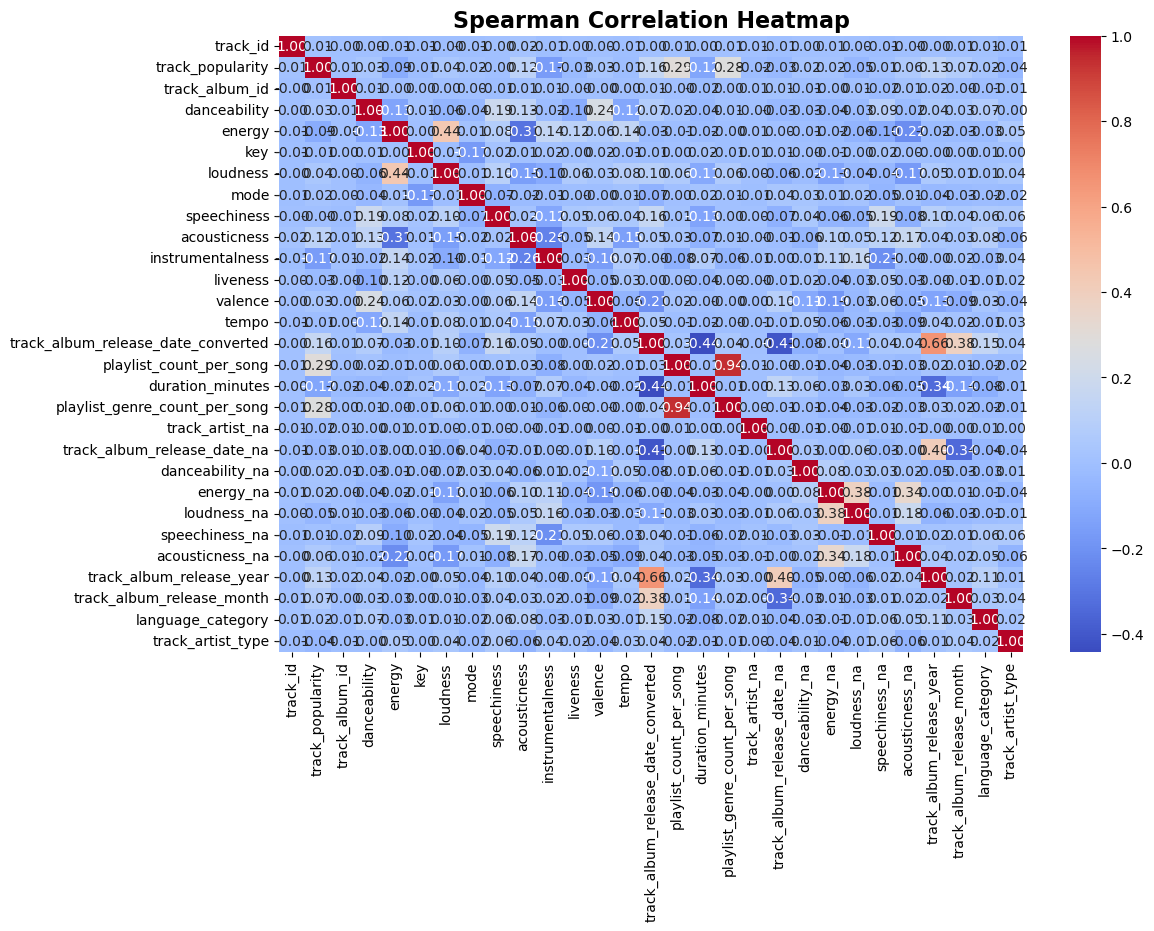

In [15]:

# Calculate the Spearman correlation matrix
spearman_corr = df.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(12, 8))  # Set the figure size for better readability
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Spearman Correlation Heatmap', fontsize=16, fontweight='bold')  # Add a title
plt.show()


In [21]:
X = df.loc[:,df.columns != 'track_popularity']
y = df['track_popularity']

In [22]:
def regressionMetrics(y, yhat):
    res = {'MSE': metrics.mean_squared_error(y,yhat),
           'RMSE': np.sqrt(metrics.mean_squared_error(y,yhat)),
           'MAE': metrics.mean_absolute_error(y,yhat),
           'RMSLE': np.sqrt(metrics.mean_squared_log_error(y,yhat)),
           'r2' :   r2_score(y, yhat)
          }
    return res

In [23]:
## Regression Models

In [24]:
models_list = pd.DataFrame()

In [28]:
model_dict = {'model': "Linear Regression"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred1)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

ValueError: Mean Squared Logarithmic Error cannot be used when targets contain negative values.

In [29]:
sns.scatterplot(x=y, y=pred1)

<Axes: xlabel='track_popularity'>

### Decision Tree

In [30]:
from sklearn.tree import DecisionTreeRegressor
mod1 = DecisionTreeRegressor(max_depth=5)  
mod1.fit(X, y)


DecisionTreeRegressor(max_depth=5)

In [31]:
pred1 = mod1.predict(X)
model_dict = {'model': "Decision Tree"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred1)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Decision Tree,459.476568,21.435405,17.872115,1.297287,0.18211


In [32]:
sns.scatterplot(x=y, y=pred1)


<Axes: xlabel='track_popularity'>

### Random Forest

In [33]:
mod2 = RandomForestRegressor(random_state=1)
mod2.fit(X,y)

RandomForestRegressor(random_state=1)

In [34]:
pred2 = mod2.predict(X)
model_dict = {'model': "RandomForest"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred2)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Decision Tree,459.476568,21.435405,17.872115,1.297287,0.182110
1,RandomForest,62.712273,7.919108,6.474769,0.861023,0.888369


In [35]:
sns.scatterplot(x=y, y=pred2)

<Axes: xlabel='track_popularity'>

### Adaptive Boosting (ADABoost)

In [36]:
mod4 = AdaBoostRegressor(random_state=1)
mod4.fit(X,y)

AdaBoostRegressor(random_state=1)

In [37]:
pred4 = mod4.predict(X)
model_dict = {'model': "ADABoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred4)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Decision Tree,459.476568,21.435405,17.872115,1.297287,0.182110
1,RandomForest,62.712273,7.919108,6.474769,0.861023,0.888369
2,ADABoost,475.735617,21.811364,18.545969,1.307542,0.153168


In [38]:
sns.scatterplot(x=y, y=pred4)

<Axes: xlabel='track_popularity'>

In [39]:
### Gradient Boosting Machine (GBM)

In [40]:
mod5 = GradientBoostingRegressor(random_state=1)
mod5.fit(X,y)

GradientBoostingRegressor(random_state=1)

In [41]:
pred5 = mod5.predict(X)
model_dict = {'model': "GBM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred5)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Decision Tree,459.476568,21.435405,17.872115,1.297287,0.182110
1,RandomForest,62.712273,7.919108,6.474769,0.861023,0.888369
2,ADABoost,475.735617,21.811364,18.545969,1.307542,0.153168
3,GBM,431.854549,20.781110,17.340703,1.281088,0.231278


In [42]:
sns.scatterplot(y=y, x=pred5)

<Axes: xlabel='track_popularity', ylabel='track_popularity'>

In [43]:
### Support Vector Machine (SVM)

In [44]:
mod6 = SVR()
mod6.fit(X,y)


SVR()

In [45]:
pred6 = mod6.predict(X)
model_dict = {'model': "SVM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred6)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Decision Tree,459.476568,21.435405,17.872115,1.297287,0.182110
1,RandomForest,62.712273,7.919108,6.474769,0.861023,0.888369
2,ADABoost,475.735617,21.811364,18.545969,1.307542,0.153168
3,GBM,431.854549,20.781110,17.340703,1.281088,0.231278
4,SVM,557.483942,23.611098,19.652322,1.382281,0.007652


In [46]:
sns.scatterplot(y=y, x=pred6)

<Axes: xlabel='track_popularity', ylabel='track_popularity'>

In [54]:
#pred2 = mod2.predict(X)
#model_dict = {'model': "XGB"}
#new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred7)}])
#models_list = pd.concat([models_list, new_row], ignore_index=True)
#print(models_list)


           model         MSE       RMSE        MAE     RMSLE        r2
0  Decision Tree  459.476568  21.435405  17.872115  1.297287  0.182110
1   RandomForest   62.712273   7.919108   6.474769  0.861023  0.888369
2       ADABoost  475.735617  21.811364  18.545969  1.307542  0.153168
3            GBM  431.854549  20.781110  17.340703  1.281088  0.231278
4            SVM  557.483942  23.611098  19.652322  1.382281  0.007652
5            XGB  252.403001  15.887196  12.807723       NaN  0.550711


In [55]:
#def regressionMetrics(y, yhat):
 #   res = {
  #      'MSE': metrics.mean_squared_error(y, yhat),
   #     'RMSE': np.sqrt(metrics.mean_squared_error(y, yhat)),
    #    'MAE': metrics.mean_absolute_error(y, yhat),
     #   'r2': r2_score(y, yhat)
   # }
    # Compute RMSLE only if y and yhat are non-negative
    #if (y >= 0).all() and (yhat >= 0).all():
    #    res['RMSLE'] = np.sqrt(metrics.mean_squared_log_error(y, yhat))
    #else:
     #   res['RMSLE'] = None  # Or np.nan to indicate it's not computed
    #return res


In [56]:
#sns.scatterplot(y=y, x=pred7)

<Axes: xlabel='track_popularity', ylabel='track_popularity'>

In [57]:
print(df[df['track_popularity'] < 0])  # Filters and prints rows where track_popularity is negative


Empty DataFrame
Columns: [track_id, track_popularity, track_album_id, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, track_album_release_date_converted, playlist_count_per_song, duration_minutes, playlist_genre_count_per_song, track_artist_na, track_album_release_date_na, danceability_na, energy_na, loudness_na, speechiness_na, acousticness_na, track_album_release_year, track_album_release_month, language_category, track_artist_type]
Index: []

[0 rows x 29 columns]


## Model Selection

Metrics:<br><b>MSE</b> - Mean Squared Error<br><b>RMSE</b> Root Mean Squared Error<br><b>MAE </b>Mean Absolute Error Calculates the average of the absolute differences between predicted and actual values.<br>
<b>RMSLE</b> Root Mean Squared Logarithmic Error

In [58]:
models_list.sort_values('MAE')

,model,MSE,RMSE,MAE,RMSLE,r2
1,RandomForest,62.712273,7.919108,6.474769,0.861023,0.888369
5,XGB,252.403001,15.887196,12.807723,NaN,0.550711
3,GBM,431.854549,20.781110,17.340703,1.281088,0.231278
0,Decision Tree,459.476568,21.435405,17.872115,1.297287,0.182110
2,ADABoost,475.735617,21.811364,18.545969,1.307542,0.153168
4,SVM,557.483942,23.611098,19.652322,1.382281,0.007652


In [59]:
models_list.sort_values('RMSE')

,model,MSE,RMSE,MAE,RMSLE,r2
1,RandomForest,62.712273,7.919108,6.474769,0.861023,0.888369
5,XGB,252.403001,15.887196,12.807723,NaN,0.550711
3,GBM,431.854549,20.781110,17.340703,1.281088,0.231278
0,Decision Tree,459.476568,21.435405,17.872115,1.297287,0.182110
2,ADABoost,475.735617,21.811364,18.545969,1.307542,0.153168
4,SVM,557.483942,23.611098,19.652322,1.382281,0.007652


In [60]:
# Splitting the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [10, 50, 100],  # Number of trees in the forest
    'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider at every split
    'max_depth': [None, 10, 20, 30, 40, 50],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required at each leaf node
}

# Create a base model
rf = RandomForestRegressor()

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=2)
#Verbose - level of details that will be provided in each iteration
# Fit the grid search to the data
grid_search.fit(X, y)

Fitting 3 folds for each of 486 candidates, totalling 1458 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
486 fits failed out of a total of 1458.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
352 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\ProgramData\anaconda3\Lib\site-packa

GridSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30, 40, 50],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 50, 100]},
             verbose=2)

In [78]:
# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", -grid_search.best_score_)

Best Parameters: {'max_depth': None, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Best Score: 449.6883916362072


In [79]:
grid_search = GridSearchCV(estimator=mod7, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", -grid_search.best_score_)


Fitting 3 folds for each of 486 candidates, totalling 1458 fits
[18:59:00] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Best Parameters: {'max_depth': None, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Best Score (MSE): 449.6883916362072


In [80]:
print("Best Score (RMSLE):", -grid_search.best_score_)

Best Score (RMSLE): 449.6883916362072


In [81]:
pred8 = grid_search.predict(X)
model_dict = {'model': "Random_Forest_FT"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred8)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Decision Tree,459.476568,21.435405,17.872115,1.297287,0.182110
1,RandomForest,62.712273,7.919108,6.474769,0.861023,0.888369
2,ADABoost,475.735617,21.811364,18.545969,1.307542,0.153168
3,GBM,431.854549,20.781110,17.340703,1.281088,0.231278
4,SVM,557.483942,23.611098,19.652322,1.382281,0.007652
5,XGB,252.403001,15.887196,12.807723,NaN,0.550711
6,Random_Forest_FT,191.301894,13.831193,11.373674,1.094948,0.659474
7,Random_Forest_FT,417.915772,20.442988,17.108331,1.260994,0.256090


In [84]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize RandomForestRegressor (corrected criterion)
rf = RandomForestRegressor(
    criterion='squared_error',  # Corrected from 'entropy'
    n_estimators=100,
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=5,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error (MSE): 448.69
R² Score: 0.20


In [87]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score  # Import correct metrics

# Initialize RandomForestRegressor
rf = RandomForestRegressor(
    criterion='squared_error',  # Corrected criterion
    n_estimators=100,
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=5,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error (MSE): 448.69
R² Score: 0.20


In [89]:
df.to_pickle ("SOPOTIFY_MODEL_SELECTION.pkl")

In [ ]:
# הייתה לי תקלה בקוד שגיליתי ברגע האחרון, ולכן לא הספקתי  להקיץ על הסוף. רשמח אם תנתן לי ההזמנות להגיש חלק זה כולל דפי הסבר